In [142]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np


folder = Path(".").resolve().parent.parent / "experiments" / "protein" / "hyper"

nn_names = ["le", "moe"]
data: dict[str, pd.DataFrame] = dict()

for run in folder.iterdir():

    if not run.is_dir():
        continue

    name = run.name.split("_")[2]

    if name not in data:
        data[name] = []

    df = pd.read_csv(run / f"{name}.csv")
    df["alg"] = name
    data[name].append(df)


data = {name: pd.concat(dfs) for name, dfs in data.items()}

# Correct normed rmse
assert (data["le"]["best_rmse_results"] <= data["le"]["rmse_results"]).all()
assert (data["moe"]["best_rmse_results"] <= data["moe"]["rmse_results"]).all()

from liquid.train import load_protein

dataset, _ = load_protein()
corrective_RMSE_factor = dataset.tensors[1].std().item()

def correct(rmse: pd.Series, T: float=0.75):
    correct_mask = rmse < T
    rmse = rmse.copy()
    rmse[correct_mask] = rmse[correct_mask] * corrective_RMSE_factor
    return rmse

data["le"]["best_rmse_results"] = correct(data["le"]["best_rmse_results"])
data["le"]["rmse_results"] = correct(data["le"]["rmse_results"])
data["moe"]["rmse_results"] = correct(data["moe"]["rmse_results"])
data["moe"]["best_rmse_results"] = correct(data["moe"]["best_rmse_results"])

# fix nans
rf_df = data["rf"]
rf_df["max_depth"] = rf_df["max_depth"].fillna(rf_df["max_depth"].max())
rf_df["max_leaf_nodes"] = rf_df["max_leaf_nodes"].fillna(rf_df["max_leaf_nodes"].max())

data["le"] = data["le"][data["le"]["confidence_power_kendall_results"].notnull()]
data["moe"] = data["moe"][data["moe"]["confidence_gate_kendall_results"].notnull()]

for name, df in data.items():
    print(name, df.shape[0])

rf 3582
moe 755
le 433
lgbm 751


In [152]:
confidence_metrics = {
    "le":"confidence_power_kendall_results",
    "moe":"confidence_gate_kendall_results",
    "rf":"confidence_std_kendall_results",
    "lgbm":"confidence_quantile_kendall_results",
}

def get_inputs(df: pd.DataFrame) -> pd.DataFrame:

    exclude = [
    "batch_size",
    "name",
    "verbose",
    "n_input",
    "n_output",
    "solver",
    "alg"
    ] + df.columns[df.columns.str.contains("results")].tolist()

    return df.drop(columns=exclude, errors="ignore")

for algo, df in data.items():

    conf_metric = confidence_metrics[algo]
    perf_metric = "best_rmse_results" if algo in nn_names else "rmse_results"

    if get_inputs(df).isnull().any().any():
        print("x", algo, "nan")

    for metric in [conf_metric, perf_metric]:

        if df[metric].isnull().any():
            print("y", algo, metric, "nan", df[metric].isnull().sum())


### Pure rmse look

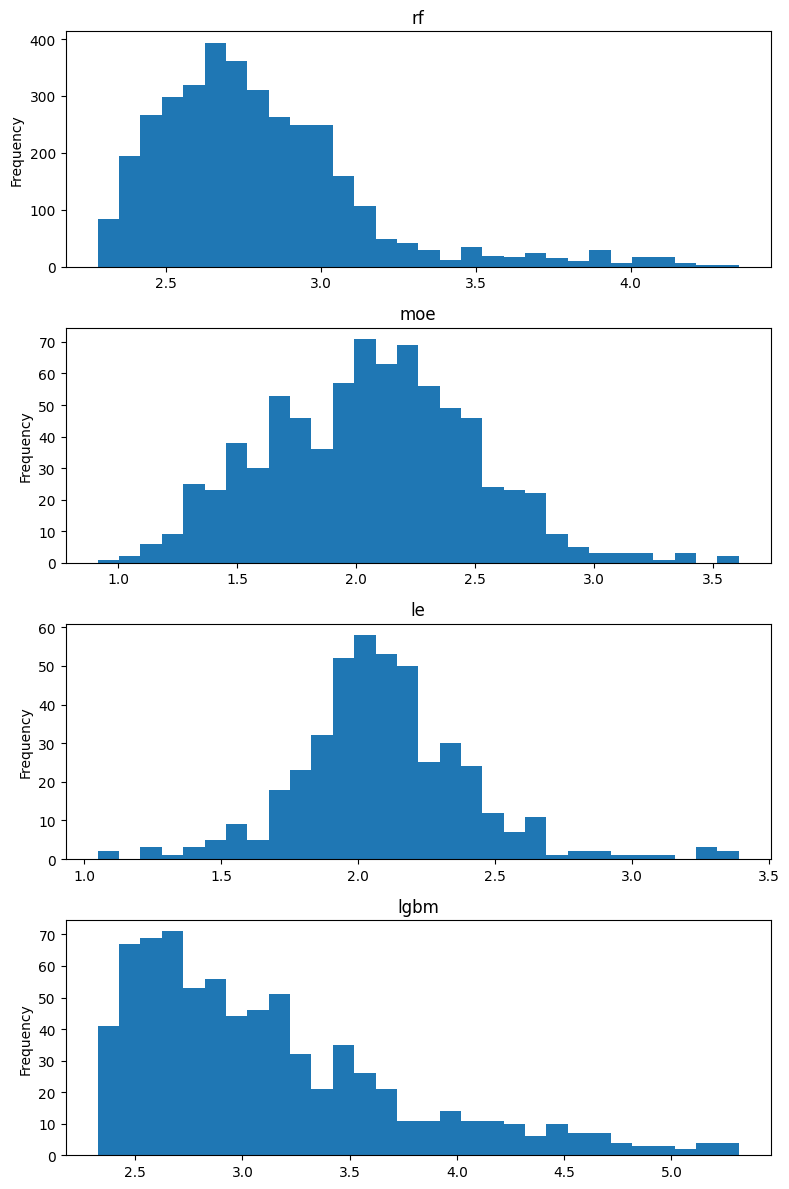

In [5]:
plt.ion()
fig, axs = plt.subplots(len(data), 1, figsize=(8, 3 * len(data)))

for (name, df), ax in zip(data.items(), axs):
    metric_name = "best_rmse_results" if name in nn_names else "rmse_results"
    metric = df[metric_name]

    metric.plot.hist(bins=30, ax=ax)
    ax.set_title(name)


fig.tight_layout()

### Nbytes over RMSE

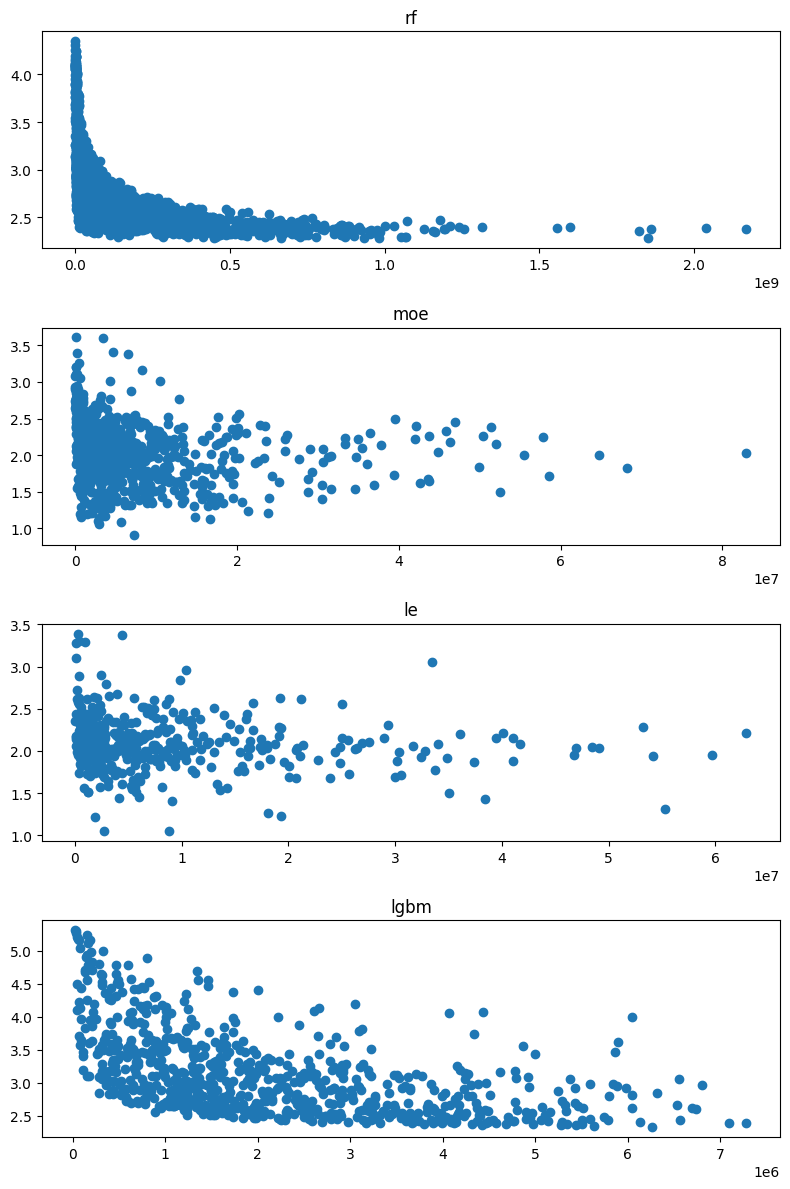

In [6]:
import numpy as np

fig, axs = plt.subplots(len(data), 1, figsize=(8, 3 * len(data)))

for (name, df), ax in zip(data.items(), axs):

    metric_name = "best_rmse_results" if name in nn_names else "rmse_results"

    x = df["nbytes_results"].to_numpy()
    y = df[metric_name].to_numpy()

    ax.scatter(x, y)
    ax.set_title(name)


fig.tight_layout()

### Stat test normalized performance by nbytes

In [7]:
def create_master_df(data: dict[str, pd.DataFrame]) -> pd.DataFrame:

    master = []
    for name, df in data.items():

        df = df.copy()


        if name in nn_names:
            df["rmse_results"] = df["best_rmse_results"].copy()

        df = df[["alg", "nbytes_results", "rmse_results", "train_time_results"]]

        master.append(df)

    master = pd.concat(master, ignore_index=True)
    master["norm_rmse"] = master["rmse_results"] / np.log(master["nbytes_results"] / 8)

    return master


master = create_master_df(data)
master.sample(3)

,alg,nbytes_results,rmse_results,train_time_results,norm_rmse
1003,rf,10200960,3.328688,97.528933,0.236773
3215,rf,54720448,2.349394,16.237634,0.149279
1011,rf,31188864,2.956683,125.707648,0.194825


In [8]:
(np.log(master["nbytes_results"])).describe()

count    5547.000000
mean       16.702817
std         2.055151
min         8.583730
25%        15.136328
50%        16.973344
75%        18.272548
max        21.498000
Name: nbytes_results, dtype: float64

In [49]:
master["norm_rmse"].describe()

count    5547.000000
mean        0.188696
std         0.056917
min         0.066667
25%         0.153037
50%         0.176758
75%         0.205859
max         0.650185
Name: norm_rmse, dtype: float64

In [50]:
master["alg"].value_counts()

alg
rf      3582
moe      778
lgbm     751
le       436
Name: count, dtype: int64

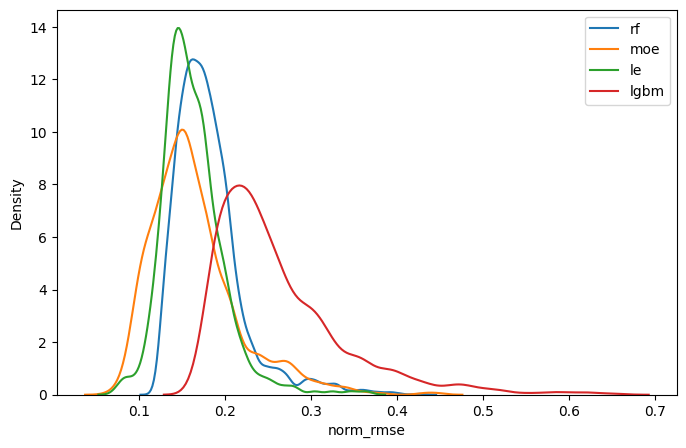

In [9]:
import seaborn as sns

n = int(master["alg"].unique().size)
fig, ax = plt.subplots(figsize=(8, 5))

for name in master["alg"].unique():
    df = master[master["alg"] == name]
    metric = df["norm_rmse"]
    sns.kdeplot(metric, ax=ax, label=name, bw_adjust=0.7)

ax.legend()

In [52]:
[name for (name, df) in master.groupby("alg")]

['le', 'lgbm', 'moe', 'rf']

In [10]:
from scipy.stats import kruskal

group_names, values = zip(*[
    (name, df["norm_rmse"].to_numpy())
    for name, df in master.groupby("alg")
])
H, p = kruskal(*values)

print(f"H-statistic: {H:.4f}")
print(f"p-value: {p:.4g}")

H-statistic: 1398.2251
p-value: 7.15e-303


Post-hoc Dunn test (p-values):
                 le           lgbm            moe             rf
le     1.000000e+00  7.918926e-179   1.000000e+00   1.657036e-19
lgbm  7.918926e-179   1.000000e+00  5.872158e-240  4.963833e-213
moe    1.000000e+00  5.872158e-240   1.000000e+00   2.854364e-28
rf     1.657036e-19  4.963833e-213   2.854364e-28   1.000000e+00


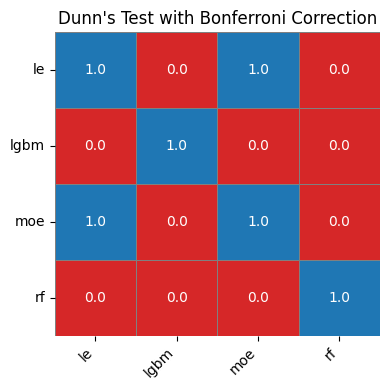

In [11]:

import scikit_posthocs as sp

# Construct DataFrame required by posthoc_dunn
df_posthoc = master[["alg", "norm_rmse"]].copy()
df_posthoc.columns = ["group", "data"]  # required names

# Dunn's pairwise test with Bonferroni correction
posthoc = sp.posthoc_dunn(df_posthoc, val_col="data", group_col="group", p_adjust="bonferroni")

print("Post-hoc Dunn test (p-values):")
print(posthoc)

# Significance mask
alpha = 0.05
signif_mask = posthoc.values < alpha

# Two-color map: red if p < 0.05, blue otherwise
cmap = sns.color_palette(["#d62728", "#1f77b4"])  # red (signif), blue (non-signif)
bool_map = np.where(signif_mask, 0, 1)  # 0: significant, 1: not significant

# Plot
plt.figure(figsize=(4, 4))
sns.heatmap(bool_map, annot=posthoc.round(4), fmt="", cmap=cmap,
            xticklabels=posthoc.columns, yticklabels=posthoc.index,
            cbar=False, linewidths=0.5, linecolor='gray')

plt.title("Dunn's Test with Bonferroni Correction")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Confidence evaluation

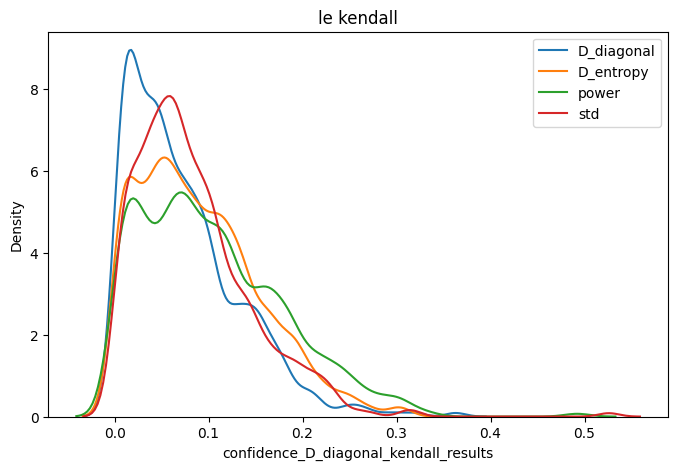

In [85]:

def plot_conf_kendall_metrics(df: pd.DataFrame, absolute: bool = False, title: str | None = None):

    fig, ax = plt.subplots(figsize=(8, 5))

    kendall_columns = df.columns[df.columns.str.contains("kendall")]

    for col in kendall_columns:

        kendall = df[col]

        if absolute:
            kendall = np.abs(kendall)

        sns.kdeplot(kendall, ax=ax, bw_adjust=0.6, label=col.replace("confidence_", "").replace("_kendall_results", ""))


    if title is None:
        title = f"{df["alg"].values[0]} kendall"

    ax.set_title(title)
    ax.legend()


plot_conf_kendall_metrics(data["le"], absolute=True)

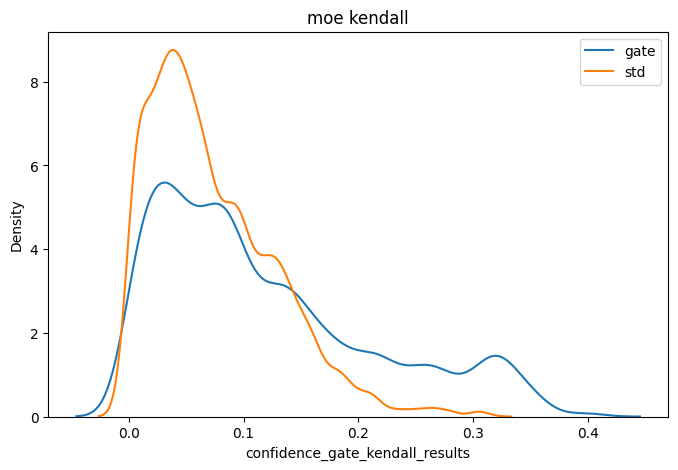

In [86]:
plot_conf_kendall_metrics(data["moe"], absolute=True)

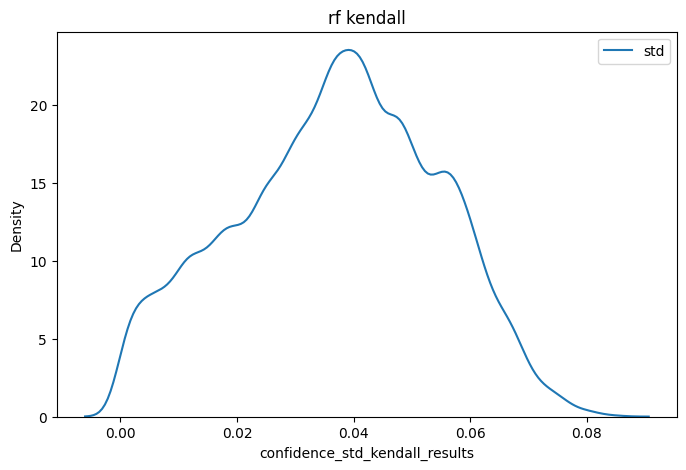

In [87]:
plot_conf_kendall_metrics(data["rf"], absolute=True)

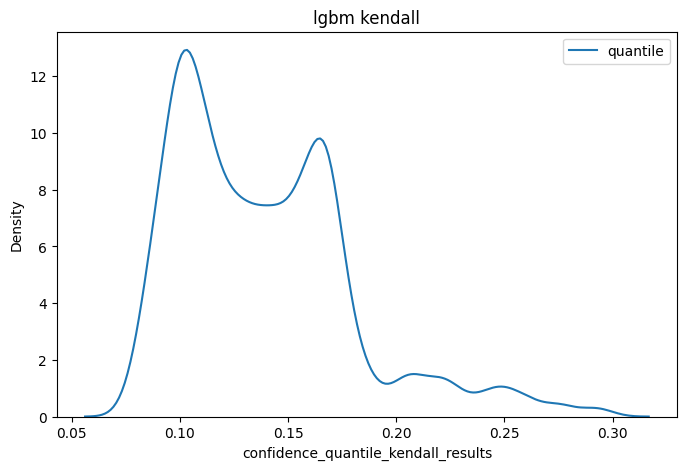

In [88]:
plot_conf_kendall_metrics(data["lgbm"], absolute=True)

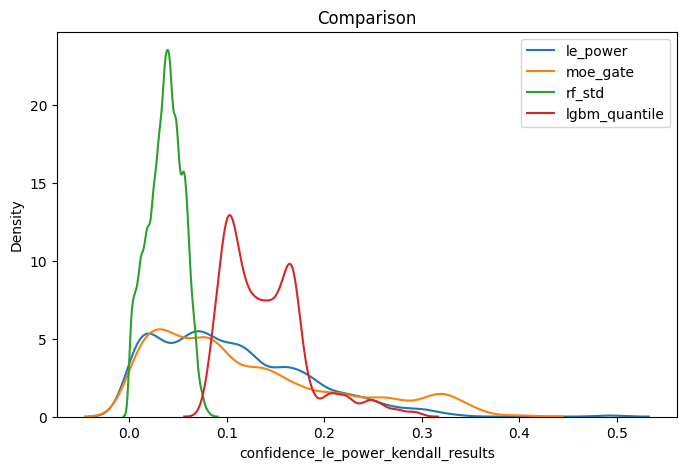

In [89]:
together = pd.concat((
    data["le"][["confidence_power_kendall_results"]].rename(columns={"confidence_power_kendall_results": "confidence_le_power_kendall_results"}),
    data["moe"][["confidence_gate_kendall_results"]].rename(columns={"confidence_gate_kendall_results": "confidence_moe_gate_kendall_results"}),
    data["rf"][["confidence_std_kendall_results"]].rename(columns={"confidence_std_kendall_results": "confidence_rf_std_kendall_results"}),
    data["lgbm"][["confidence_quantile_kendall_results"]].rename(columns={"confidence_quantile_kendall_results": "confidence_lgbm_quantile_kendall_results"}),
), ignore_index=True)

plot_conf_kendall_metrics(together, absolute=True, title="Comparison")

### Shapley value

In [144]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

import shapiq
import pickle

def to_numpy(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:

    df = df.copy()

    ok_columns = df.select_dtypes(include='number').columns
    bad_columns = df.columns[~df.columns.isin(ok_columns)]

    if bad_columns.size == 0:
        return df.to_numpy(), df.columns.to_numpy()

    print(bad_columns.tolist(), "will be converted to categorical value")

    for col in bad_columns:
        df[col] = df[col].astype("category").cat.codes


    return df.to_numpy(), df.columns.to_numpy()


def check_for_too_large_errors(X: np.ndarray, y: np.ndarray, model: RandomForestRegressor, tsr: float = 0.05):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=tsr)
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    mae = mean_absolute_error(y_test, yhat)
    print("Surrogate model validation mae", mae)




def explain_model_metric(df: pd.DataFrame, metric: str, model: str, tree: bool=False):

    surrogate = RandomForestRegressor(n_estimators=10, warm_start=False)

    X, feature_names = to_numpy(get_inputs(df))
    y = df[metric].to_numpy()

    check_for_too_large_errors(X, y, surrogate)

    surrogate.fit(X, y)

    if not tree:

        explainer = shapiq.TabularExplainer(
            model=surrogate,
            data=X,
            index="k-SII",
            approximator="svarm",
            max_order=2
        )

        explanations = explainer.explain_X(
            X,
            budget=256,
            verbose=True,
            n_jobs=4
        )
    else:

        explainer = shapiq.TreeExplainer(
            model=surrogate,
            data=X,
            index="k-SII",
            max_order=2
        )

        explanations = explainer.explain_X(
            X,
            verbose=True,
            n_jobs=4
        )


    save_explanations(df, metric, model, feature_names, explanations)

    return df, explanations, feature_names

def save_explanations(df, metric, model, feature_names, explanations):
    feat_names_path = f"./{model}_{metric}_names.pkl"
    explanations_path = f"./{model}_{metric}_expl.pkl"
    df_path = f"./{model}_{metric}_df.csv"

    with open(feat_names_path, "wb") as f:
        pickle.dump(feature_names, f)

    with open(explanations_path, "wb") as f:
        pickle.dump(explanations, f)

    df.to_csv(df_path, index=False)

def load_explanations(metric, model):
    feat_names_path = f"./{model}_{metric}_names.pkl"
    explanations_path = f"./{model}_{metric}_expl.pkl"
    df_path = f"./{model}_{metric}_df.csv"

    with open(feat_names_path, "rb") as f:
        feature_names = pickle.load(f)

    with open(explanations_path, "rb") as f:
        explanations = pickle.load(f)

    df = pd.read_csv(df_path)

    return df, explanations, feature_names

In [ ]:
surrogate = RandomForestRegressor(n_estimators=10, warm_start=False)

test = "rf"

X, feature_names = to_numpy(get_inputs(data[test]))
y = data[test]["best_rmse_results"].to_numpy()

check_for_too_large_errors(X, y, surrogate)

surrogate.fit(X, y)

explainer = shapiq.TreeExplainer(
    model=surrogate,
    data=X,
    index="k-SII",
    max_order=2
)

explainer.explain(X[11])

KeyError: 'best_rmse_results'

### Save explanations

In [145]:

import tqdm


confidence_metrics = {
    "le":"confidence_power_kendall_results",
    "moe":"confidence_gate_kendall_results",
    "rf":"confidence_std_kendall_results",
    "lgbm":"confidence_quantile_kendall_results",
}

for algo, df in tqdm.tqdm(list(data.items())):

    conf_metric = confidence_metrics[algo]
    perf_metric = "best_rmse_results" if algo in nn_names else "rmse_results"

    if df.shape[0] > 800:
        print(algo, "to 800 rows")
        df = df.sample(800)

    for metric in [perf_metric, conf_metric]:
        explain_model_metric(df, metric, algo, tree=True)

  0%|          | 0/4 [00:00<?, ?it/s]

rf to 800 rows
Surrogate model validation mae 0.04488402047280014
Surrogate model validation mae 0.009829679970769849


 25%|██▌       | 1/4 [24:18<1:12:55, 1458.34s/it]

Surrogate model validation mae 0.27889776022679846
Surrogate model validation mae 0.07716973858694477


 50%|█████     | 2/4 [47:11<46:56, 1408.12s/it]  

Surrogate model validation mae 0.22069003771732054
Surrogate model validation mae 0.0870146316762672


 75%|███████▌  | 3/4 [55:56<16:44, 1004.88s/it]

['boosting'] will be converted to categorical value
Surrogate model validation mae 0.07731534986376569
['boosting'] will be converted to categorical value
Surrogate model validation mae 0.008799795993813241


100%|██████████| 4/4 [1:16:15<00:00, 1143.92s/it]


In [150]:
get_inputs(data["le"]).columns

Index(['dropout_body', 'dropout_d', 'dropout_y', 'epoch', 'layers_body',
       'layers_d', 'layers_y', 'load_distribution_lambda', 'lr', 'n_citizens',
       'nbytes_results', 'specialization_lambda', 'train_time_results',
       'width_body', 'width_d', 'width_y'],
      dtype='object')

In [146]:
df, explanations, feature_names = load_explanations("best_rmse_results", "le")

In [147]:
from shapiq.interaction_values import aggregate_interaction_values

global_explanation = aggregate_interaction_values(explanations, aggregation="mean")

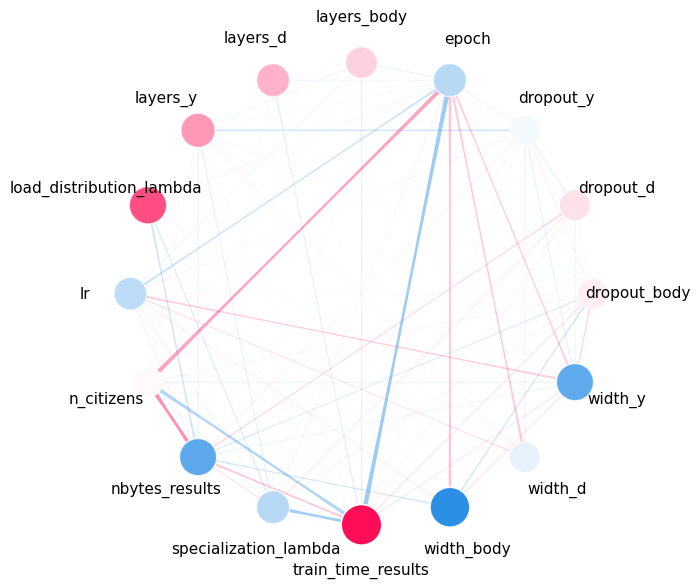

In [148]:
global_explanation.plot_network(feature_names=feature_names)

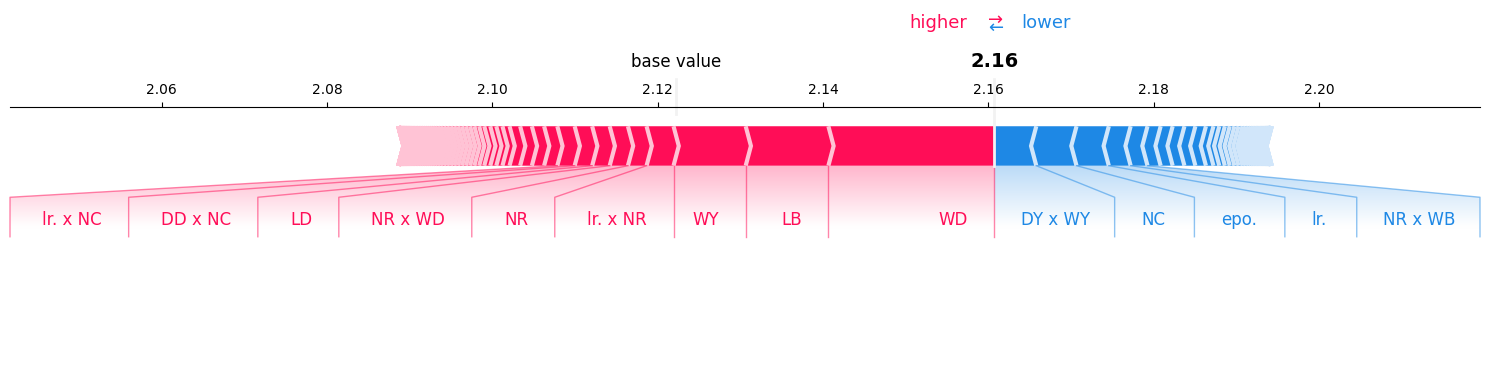

In [63]:
global_explanation.plot_force(contribution_threshold=0.02, feature_names=feature_names, abbreviate=True)

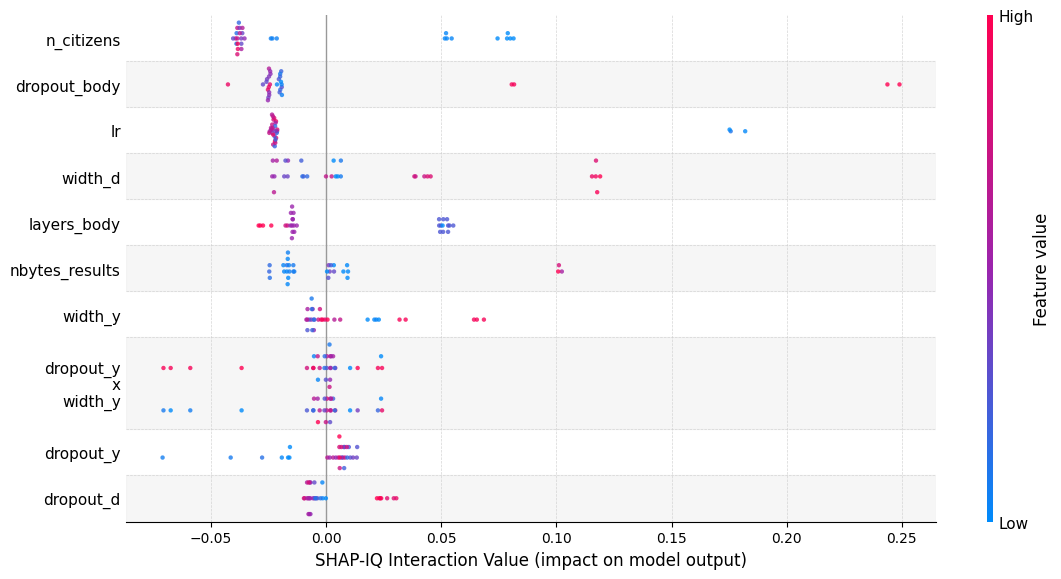

In [64]:
shapiq.beeswarm_plot(explanations, to_numpy(get_inputs(df))[0], feature_names=feature_names, abbreviate=False)

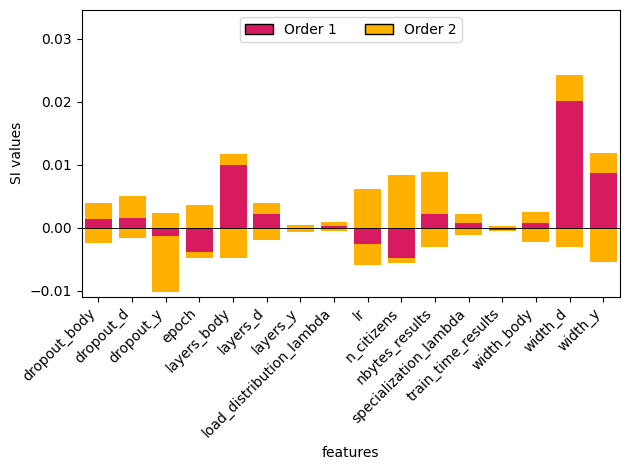

In [59]:
global_explanation.plot_stacked_bar(feature_names=feature_names)

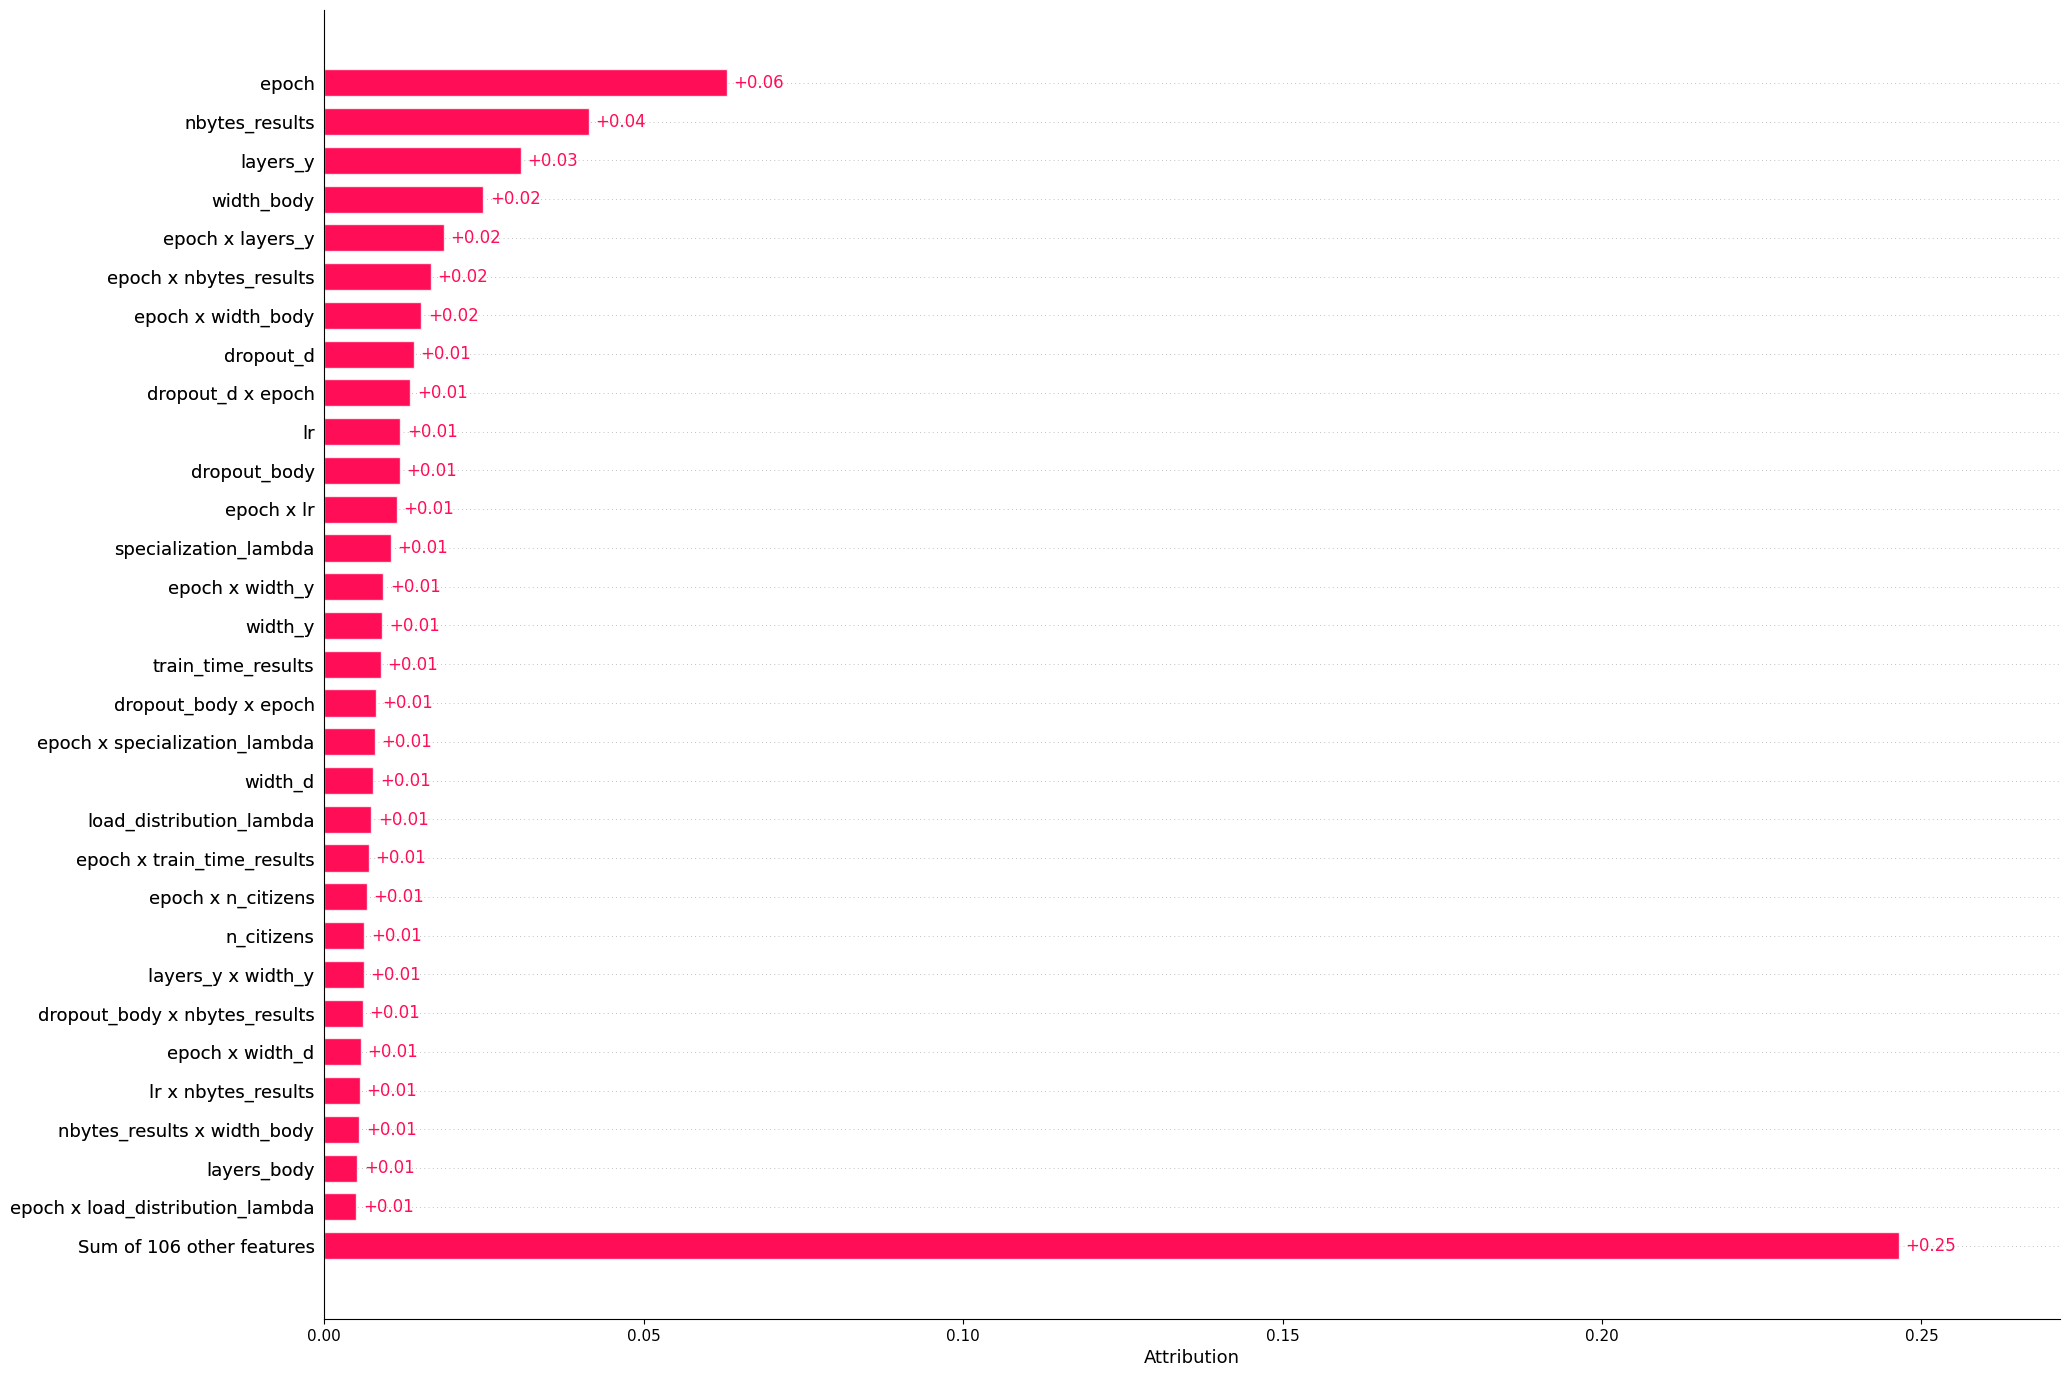

In [286]:
shapiq.plot.bar_plot(explanations, feature_names=feature_names, abbreviate=False, show=True, max_display=30)

In [211]:
get_inputs(data["rf"]).columns.size

8

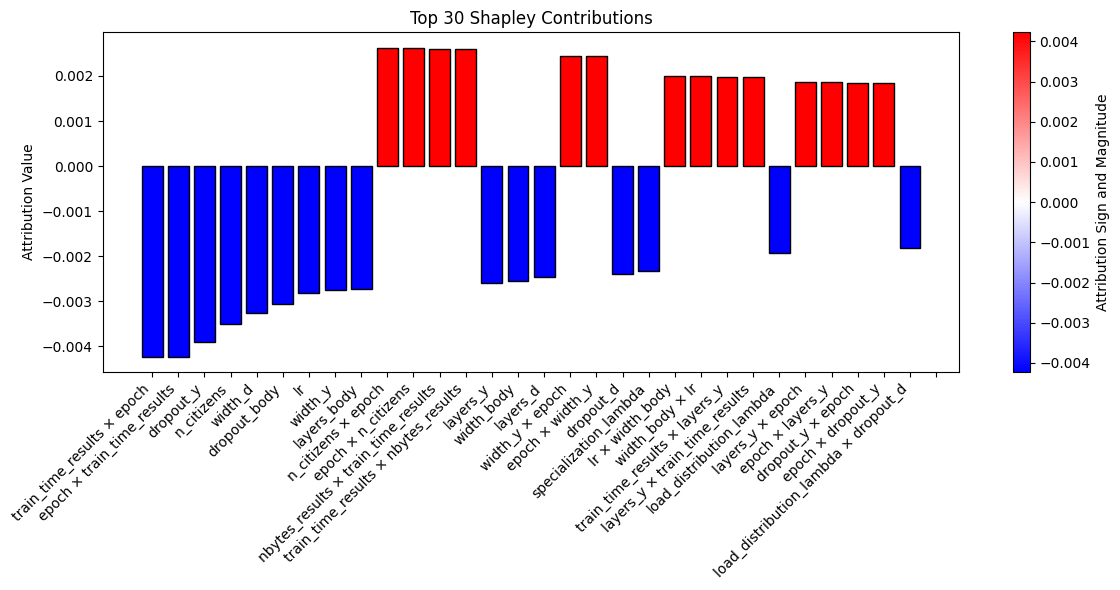

In [207]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_top_shap_contributions(*shap_arrays, feature_names: np.ndarray, top: int = 10, plot_rest: bool = False):
    N = feature_names.shape[0]
    flat_entries = []
    labels = []

    for arr in shap_arrays:
        it = np.ndindex(arr.shape)
        for idx in it:
            val = arr[idx]
            label = tuple(feature_names[i] for i in idx)
            flat_entries.append(val)
            labels.append(label)

    flat_entries = np.array(flat_entries)
    magnitudes = np.abs(flat_entries)
    sorted_indices = np.argsort(-magnitudes)
    top_indices = sorted_indices[:top]
    rest_indices = sorted_indices[top:]

    top_vals = flat_entries[top_indices]
    top_labels = [labels[i] for i in top_indices]
    rest_sum = np.sum(np.abs(flat_entries[rest_indices]))

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['red' if v >= 0 else 'blue' for v in top_vals]
    ax.bar(range(top), top_vals, color=colors, edgecolor='black')

    if plot_rest:
        vmax = max(top_vals.max(), rest_sum)
        ax.bar(top, rest_sum, color='gray', edgecolor='black')
    else:
        vmax = top_vals.max()


    vmin = top_vals.min()
    if (-vmin) > vmax:
        vmax = -vmin
    else:
        vmin = -vmax

    xticks = [' × '.join(lbl) for lbl in top_labels] + (['Rest'] if plot_rest else [""])
    ax.set_xticks(range(top + 1))
    ax.set_xticklabels(xticks, rotation=45, ha='right')
    ax.set_ylabel("Attribution Value")
    ax.set_title(f"Top {top} Shapley Contributions")



    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(cmap='bwr', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Attribution Sign and Magnitude')

    plt.tight_layout()
    plt.show()

plot_top_shap_contributions(
    global_explanation.get_n_order_values(1),
    global_explanation.get_n_order_values(2),
    global_explanation.get_n_order_values(3),
    top=30,
    feature_names=feature_names,
    plot_rest=False
)


In [212]:
global_explanation.n_players

16

In [103]:
data["rf"].select_dtypes("object")

,name
0,protein
1,protein
2,protein
3,protein
4,protein
...,...
571,protein
572,protein
573,protein
574,protein


In [223]:
def check(df: pd.DataFrame, metric: str):
    surrogate = RandomForestRegressor(n_estimators=100, warm_start=False)

    X, feature_names = to_numpy(get_inputs(df))
    y = df[metric].to_numpy()

    check_for_too_large_errors(X, y, surrogate, tsr=0.2)

    surrogate.fit(X, y)

    yhat = surrogate.predict(X)
    print(yhat.std())

check(data["le"], "best_rmse_results")

Surrogate model validation rmse 0.24763220967020225
0.22642694530914909
